In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

decision_tree_estimators_dict = {
    "Decision Tree": estimators_dict["Decision Tree"],
    "Decision Tree Balanced": estimators_dict["Decision Tree Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_dt, threshold_comparison_dt, confusion_results_dt, trained_models_dt, interpretation_results_dt = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=decision_tree_estimators_dict,
    target=target
)

general_comparison_dt.sort_values(by=["F1-score", "AUC"], ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
9,Modelo 5 — Estabilidade e Benefícios,Decision Tree Balanced,0.5,0.744,0.350,0.690,0.464,0.758,0,9,24
3,Modelo 2 — Nível Hierárquico,Decision Tree Balanced,0.5,0.751,0.344,0.606,0.439,0.724,0,8,22
11,Modelo 6 — Perfil Pessoal,Decision Tree Balanced,0.5,0.703,0.312,0.704,0.433,0.762,0,9,24
19,Modelo 3 — Rendimento Quantitativo,Decision Tree Balanced,0.5,0.721,0.322,0.662,0.433,0.744,4,6,19
27,Modelo 7 — Reduzido Conservador Misto,Decision Tree Balanced,0.5,0.717,0.318,0.662,0.429,0.692,3,6,18
7,Modelo 4 — Trajetória Organizacional,Decision Tree Balanced,0.5,0.762,0.348,0.549,0.426,0.727,0,8,22
1,Modelo 1 — Função Profissional,Decision Tree Balanced,0.5,0.712,0.313,0.662,0.425,0.711,0,8,26
5,Modelo 3 — Faixa Salarial,Decision Tree Balanced,0.5,0.766,0.346,0.507,0.411,0.738,0,8,21
15,Modelo 1 — Função Profissional Misto,Decision Tree Balanced,0.5,0.717,0.307,0.606,0.408,0.702,3,7,26
23,Modelo 5 — Antiguidade Organizacional,Decision Tree Balanced,0.5,0.698,0.296,0.634,0.404,0.704,5,6,20


In [4]:
best_thresholds_dt = threshold_comparison_dt.loc[
    threshold_comparison_dt.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_dt.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
7,Modelo 2 — Nível Hierárquico e Benefícios,Decision Tree Balanced,0.600,0.803,0.423,0.620,0.503,0.739
4,Modelo 2 — Nível Hierárquico,Decision Tree,0.200,0.791,0.402,0.606,0.483,0.723
18,Modelo 5 — Estabilidade e Benefícios,Decision Tree,0.200,0.778,0.385,0.634,0.479,0.774
19,Modelo 5 — Estabilidade e Benefícios,Decision Tree Balanced,0.600,0.816,0.439,0.507,0.471,0.758
21,Modelo 6 — Perfil Pessoal,Decision Tree Balanced,0.525,0.762,0.363,0.634,0.462,0.762
5,Modelo 2 — Nível Hierárquico,Decision Tree Balanced,0.550,0.766,0.362,0.592,0.449,0.724
20,Modelo 6 — Perfil Pessoal,Decision Tree,0.200,0.782,0.379,0.549,0.448,0.747
0,Modelo 1 — Função Profissional,Decision Tree,0.200,0.798,0.398,0.493,0.440,0.750
23,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Decision Tree Balanced,0.575,0.764,0.354,0.563,0.435,0.721
15,Modelo 4 — Trajetória Organizacional,Decision Tree Balanced,0.375,0.705,0.314,0.704,0.435,0.727


In [5]:
top_5_best_dt = best_thresholds_dt.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_dt

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 2 — Nível Hierárquico e Benefícios,Decision Tree Balanced,0.600,0.803,0.423,0.620,0.503,0.739
1,Modelo 2 — Nível Hierárquico,Decision Tree,0.200,0.791,0.402,0.606,0.483,0.723
2,Modelo 5 — Estabilidade e Benefícios,Decision Tree,0.200,0.778,0.385,0.634,0.479,0.774
3,Modelo 5 — Estabilidade e Benefícios,Decision Tree Balanced,0.600,0.816,0.439,0.507,0.471,0.758
4,Modelo 6 — Perfil Pessoal,Decision Tree Balanced,0.525,0.762,0.363,0.634,0.462,0.762


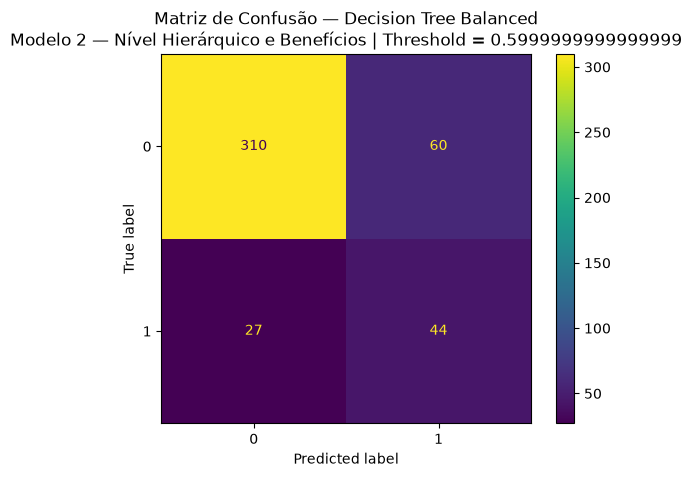

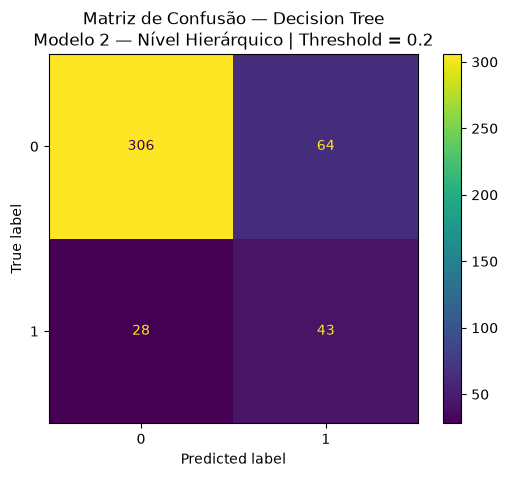

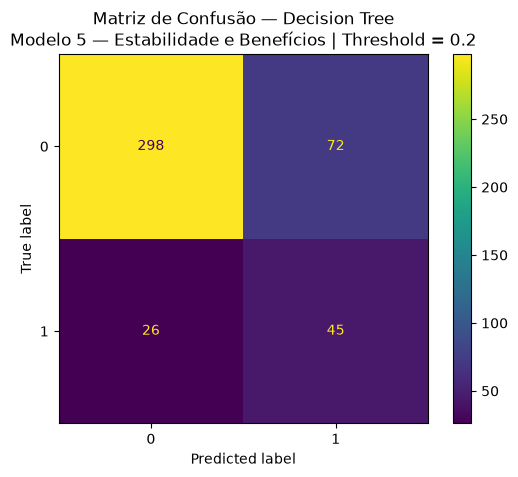

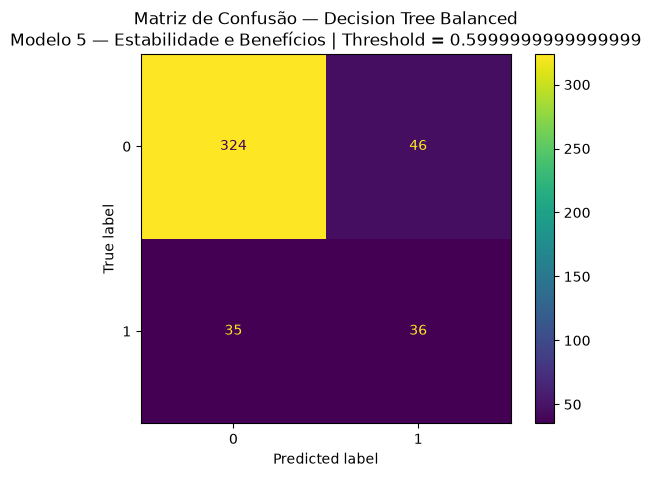

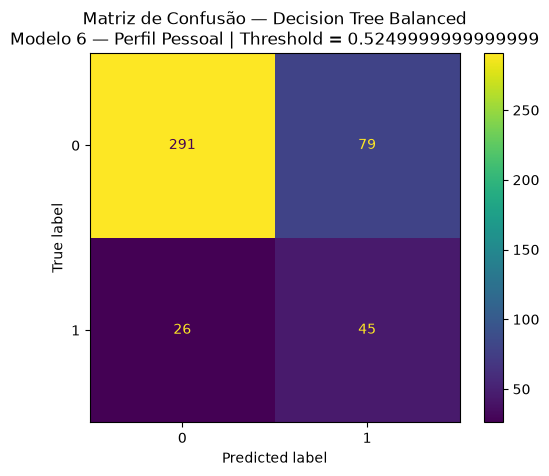

In [6]:
for _, row in top_5_best_dt.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(decision_tree_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train, y_train)
    
    y_prob = estimator.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

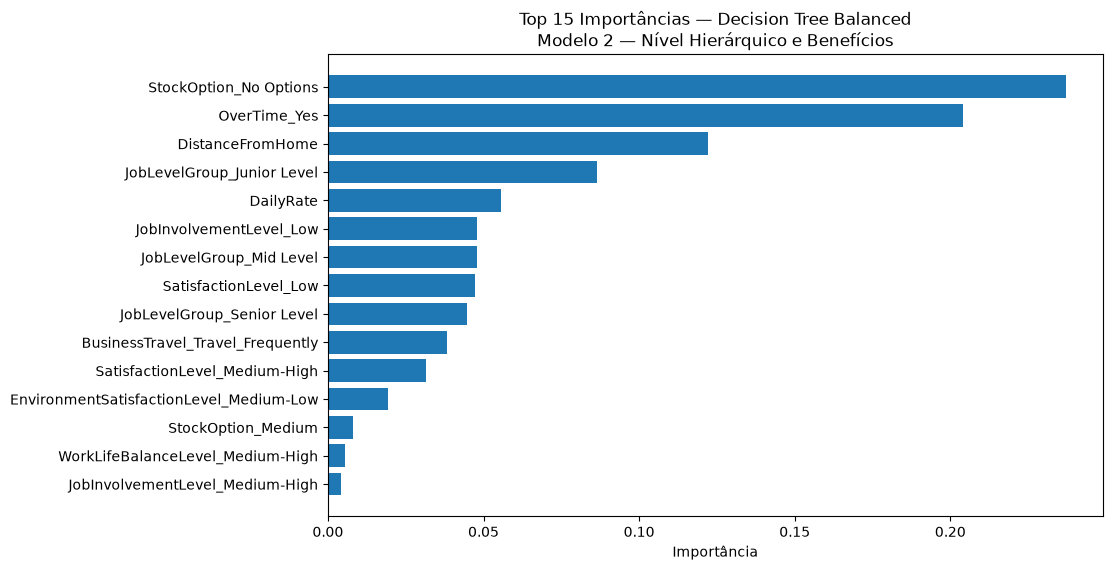

,Feature,Importance
10,StockOption_No Options,0.237166
3,OverTime_Yes,0.203957
0,DistanceFromHome,0.122253
5,JobLevelGroup_Junior Level,0.086423
1,DailyRate,0.055545
13,JobInvolvementLevel_Low,0.048046
6,JobLevelGroup_Mid Level,0.047909
19,SatisfactionLevel_Low,0.047123
7,JobLevelGroup_Senior Level,0.044556
11,BusinessTravel_Travel_Frequently,0.038244


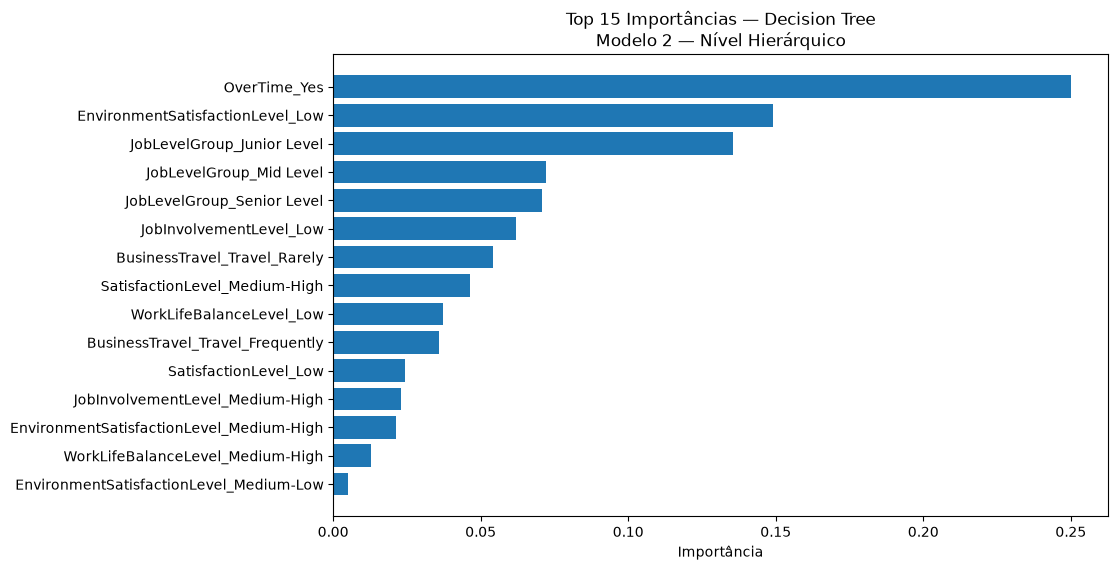

,Feature,Importance
0,OverTime_Yes,0.250146
10,EnvironmentSatisfactionLevel_Low,0.149092
2,JobLevelGroup_Junior Level,0.135556
3,JobLevelGroup_Mid Level,0.072109
4,JobLevelGroup_Senior Level,0.070836
7,JobInvolvementLevel_Low,0.061824
6,BusinessTravel_Travel_Rarely,0.054243
14,SatisfactionLevel_Medium-High,0.046323
16,WorkLifeBalanceLevel_Low,0.037266
5,BusinessTravel_Travel_Frequently,0.035936


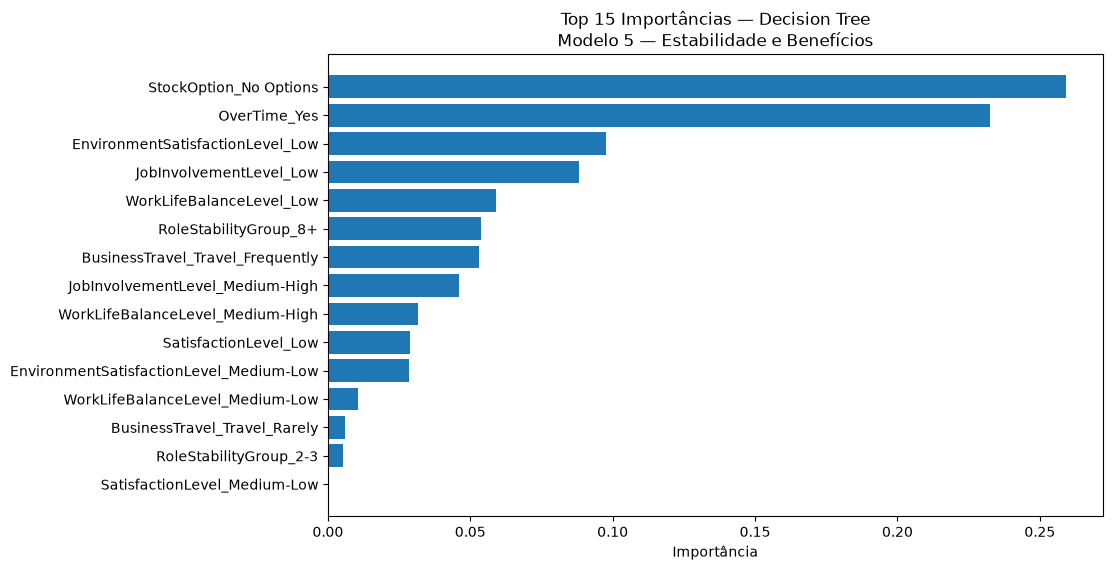

,Feature,Importance
6,StockOption_No Options,0.259191
0,OverTime_Yes,0.232528
12,EnvironmentSatisfactionLevel_Low,0.097578
9,JobInvolvementLevel_Low,0.088126
18,WorkLifeBalanceLevel_Low,0.059090
3,RoleStabilityGroup_8+,0.053606
7,BusinessTravel_Travel_Frequently,0.053059
10,JobInvolvementLevel_Medium-High,0.045896
19,WorkLifeBalanceLevel_Medium-High,0.031658
15,SatisfactionLevel_Low,0.028709


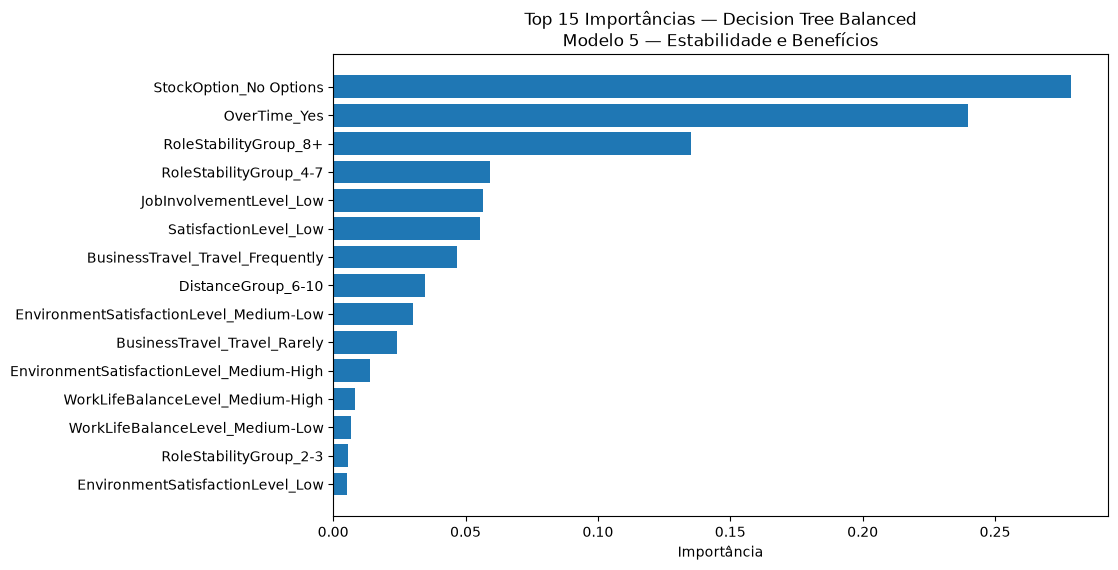

,Feature,Importance
6,StockOption_No Options,0.278778
0,OverTime_Yes,0.239743
3,RoleStabilityGroup_8+,0.135190
2,RoleStabilityGroup_4-7,0.059350
9,JobInvolvementLevel_Low,0.056477
15,SatisfactionLevel_Low,0.055392
7,BusinessTravel_Travel_Frequently,0.046634
23,DistanceGroup_6-10,0.034833
14,EnvironmentSatisfactionLevel_Medium-Low,0.030121
8,BusinessTravel_Travel_Rarely,0.023949


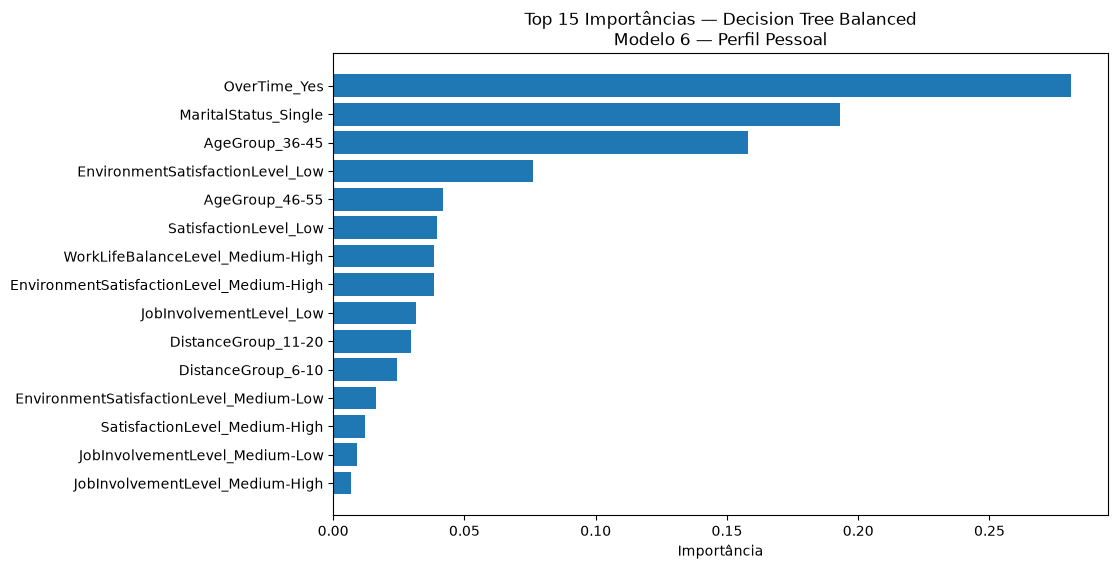

,Feature,Importance
0,OverTime_Yes,0.281141
6,MaritalStatus_Single,0.193146
2,AgeGroup_36-45,0.157858
12,EnvironmentSatisfactionLevel_Low,0.076240
3,AgeGroup_46-55,0.041821
15,SatisfactionLevel_Low,0.039688
19,WorkLifeBalanceLevel_Medium-High,0.038466
13,EnvironmentSatisfactionLevel_Medium-High,0.038300
9,JobInvolvementLevel_Low,0.031560
21,DistanceGroup_11-20,0.029564


In [7]:
for _, row in top_5_best_dt.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_dt[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Importância")
    plt.title(f"Top 15 Importâncias — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

SHAP — Decision Tree Balanced | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


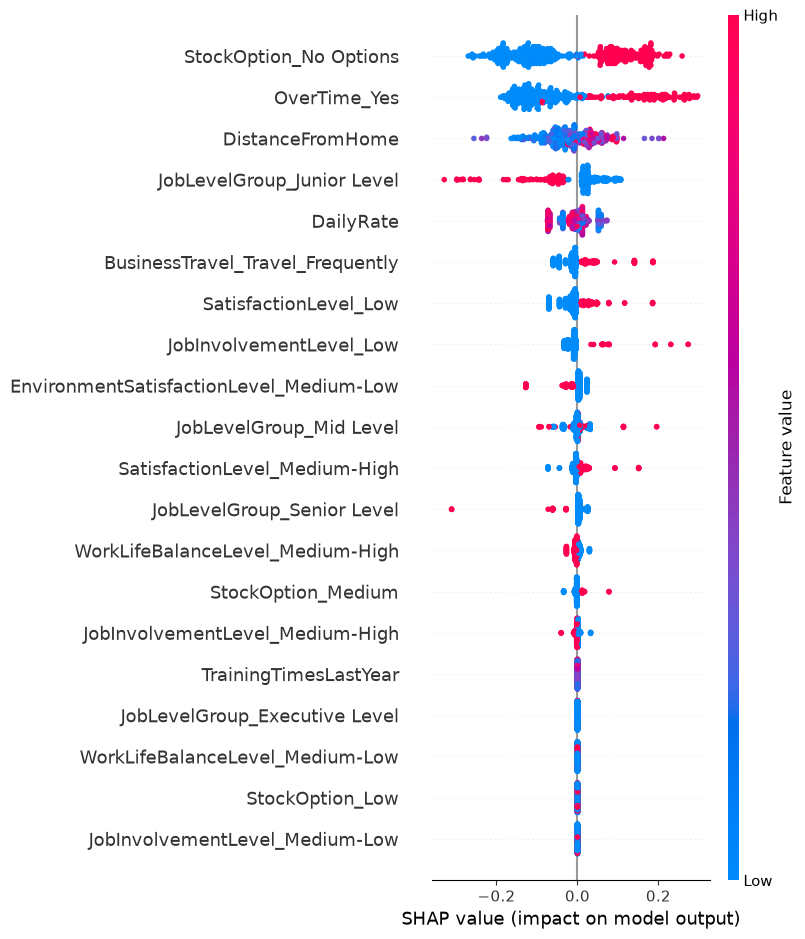

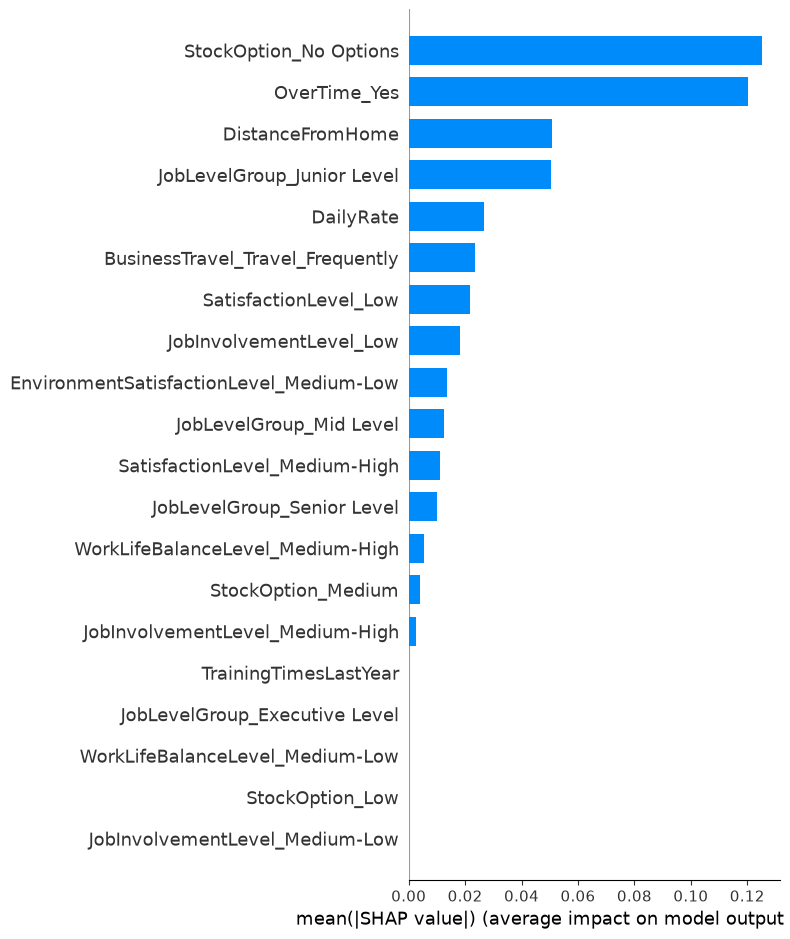

SHAP — Decision Tree | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


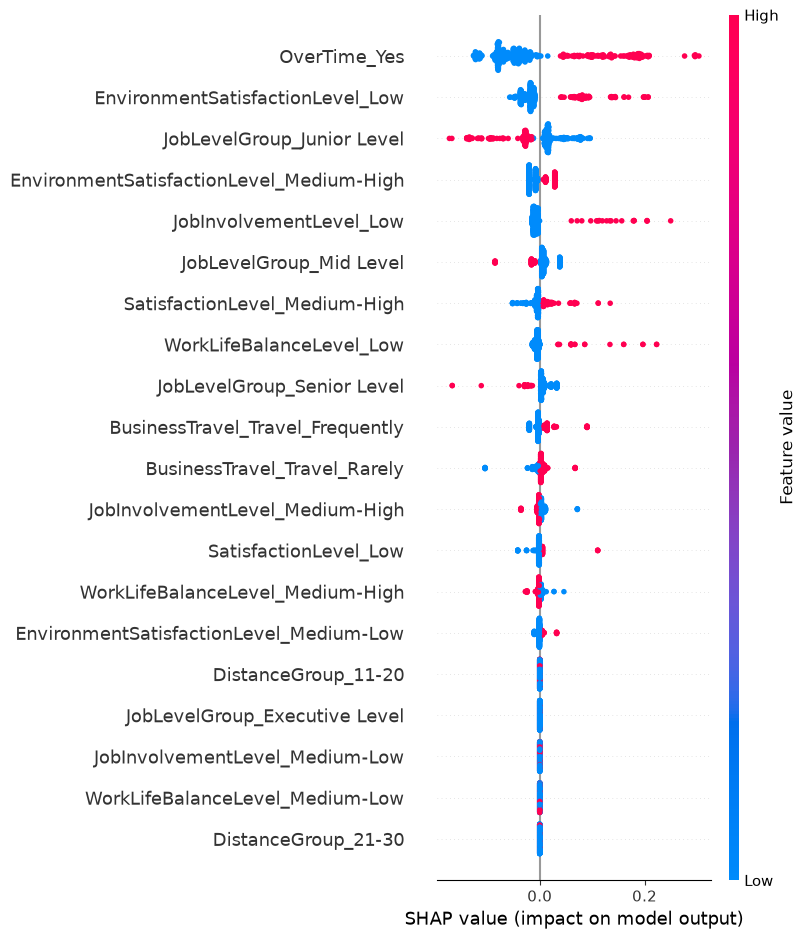

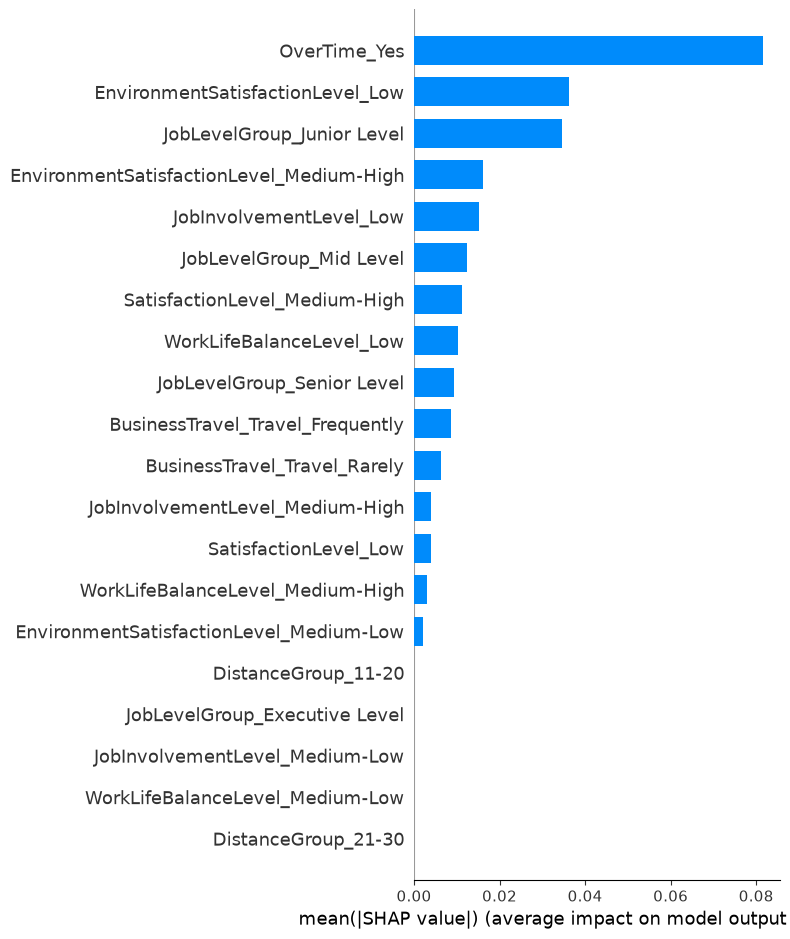

SHAP — Decision Tree | Modelo 5 — Estabilidade e Benefícios
(441, 24)
(441, 24)


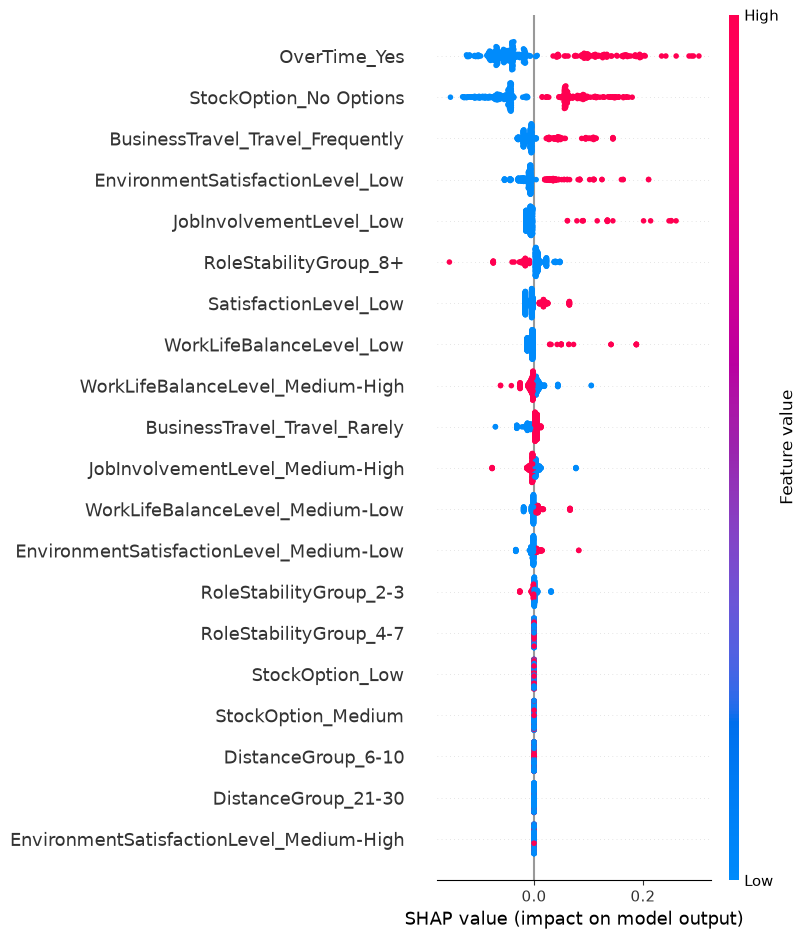

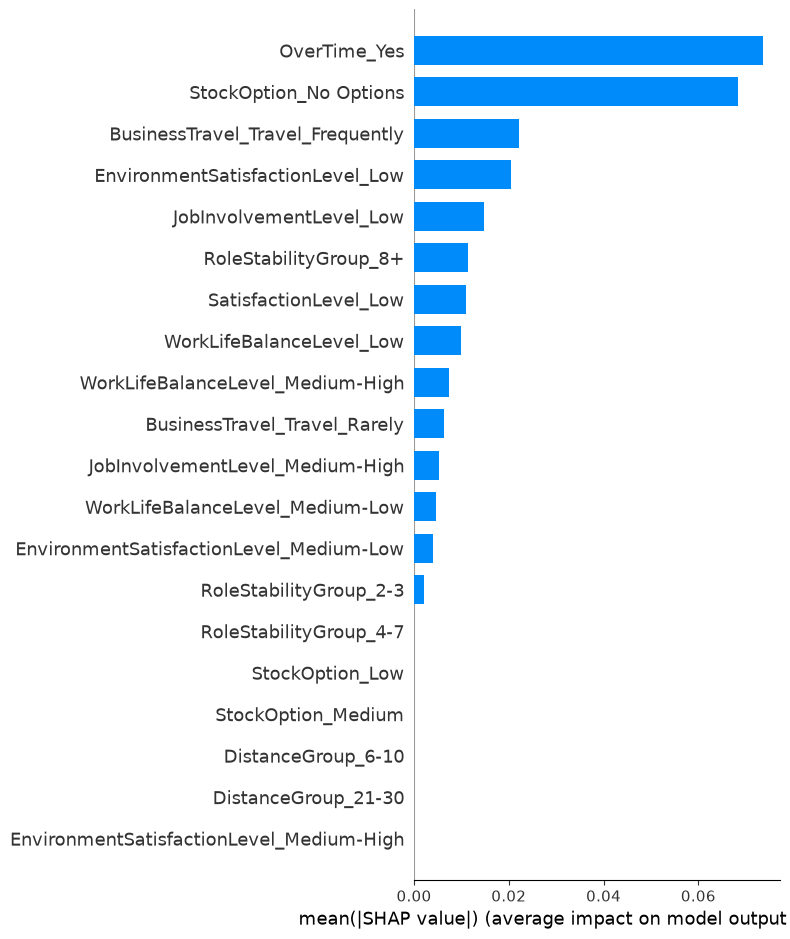

SHAP — Decision Tree Balanced | Modelo 5 — Estabilidade e Benefícios
(441, 24)
(441, 24)


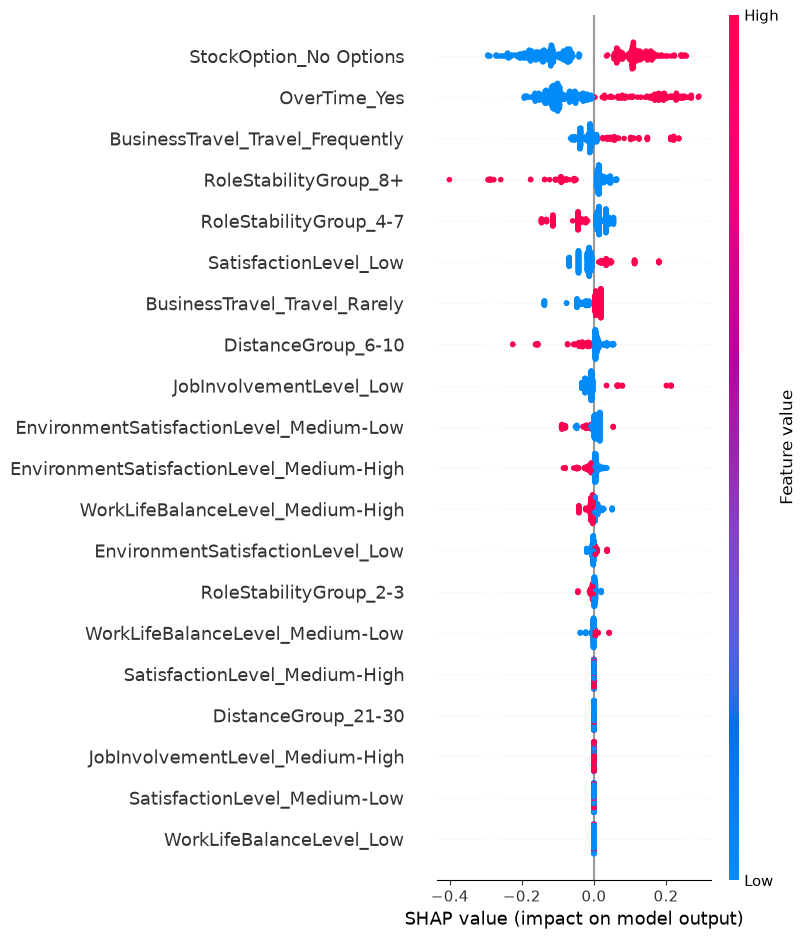

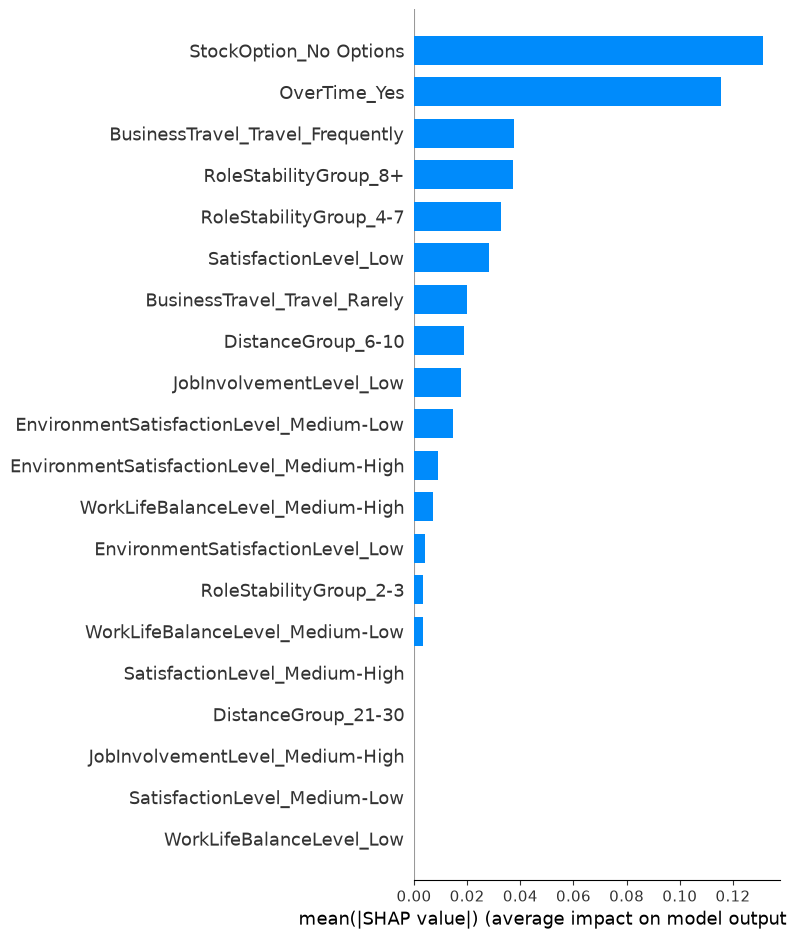

SHAP — Decision Tree Balanced | Modelo 6 — Perfil Pessoal
(441, 24)
(441, 24)


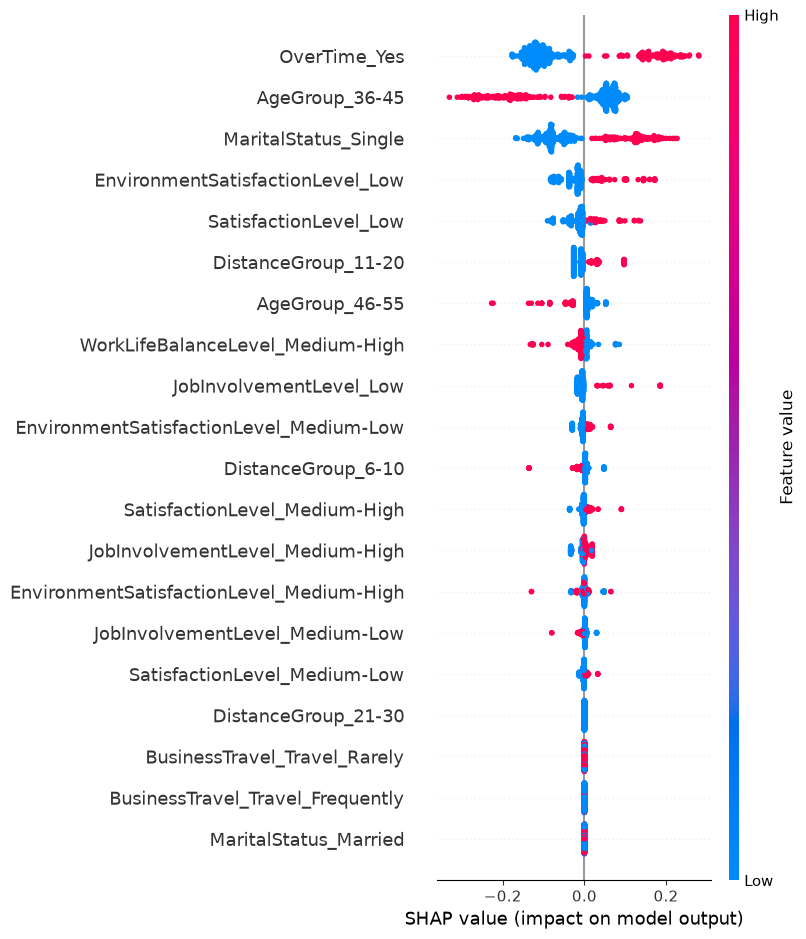

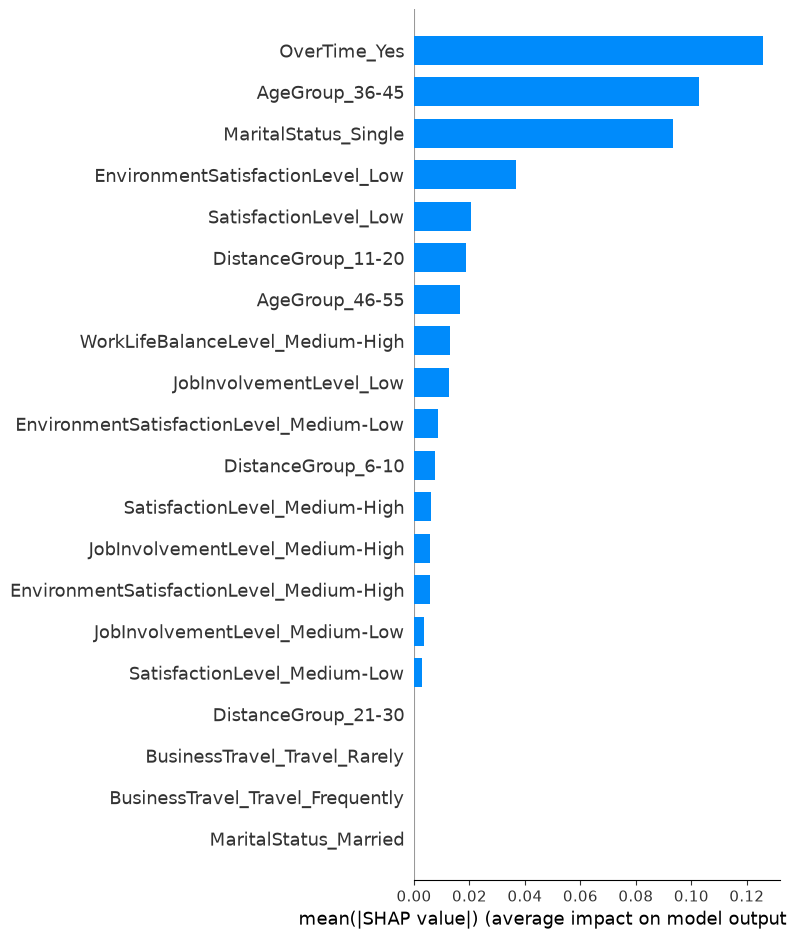

In [8]:
for _, row in top_5_best_dt.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(decision_tree_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    print(shap_values_class1.shape)
    print(X_test.shape)
    
    shap.summary_plot(shap_values_class1, X_test)
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# Validação Cruzada

In [9]:
cv_decision_tree = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "Decision Tree": estimators_dict["Decision Tree"],
        "Decision Tree Balanced": estimators_dict["Decision Tree Balanced"]
    },
    target="AttritionFlag"
)

cv_decision_tree.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
9,Modelo 5 — Estabilidade e Benefícios,Decision Tree Balanced,0.729,0.051,0.327,0.066,0.611,0.095,0.424,0.072,0.712,0.058,0,9,24
29,Modelo 8 — Integrado Multidimensional,Decision Tree Balanced,0.733,0.048,0.328,0.086,0.561,0.083,0.408,0.066,0.701,0.044,7,11,43
17,Modelo 2 — Nível Hierárquico e Benefícios,Decision Tree Balanced,0.727,0.044,0.317,0.061,0.578,0.094,0.408,0.070,0.685,0.062,3,8,25
28,Modelo 8 — Integrado Multidimensional,Decision Tree,0.844,0.022,0.541,0.145,0.334,0.104,0.403,0.094,0.705,0.044,7,11,43
5,Modelo 3 — Faixa Salarial,Decision Tree Balanced,0.706,0.052,0.304,0.043,0.594,0.078,0.397,0.025,0.706,0.041,0,8,21
1,Modelo 1 — Função Profissional,Decision Tree Balanced,0.676,0.038,0.280,0.036,0.637,0.090,0.388,0.046,0.689,0.058,0,8,26
3,Modelo 2 — Nível Hierárquico,Decision Tree Balanced,0.732,0.040,0.311,0.049,0.519,0.075,0.385,0.045,0.698,0.071,0,8,22
19,Modelo 3 — Rendimento Quantitativo,Decision Tree Balanced,0.720,0.065,0.307,0.083,0.531,0.113,0.385,0.089,0.705,0.068,4,6,19
13,Modelo 7 — Reduzido Conservador,Decision Tree Balanced,0.693,0.040,0.287,0.038,0.595,0.097,0.385,0.046,0.686,0.054,0,7,18
15,Modelo 1 — Função Profissional Misto,Decision Tree Balanced,0.660,0.043,0.271,0.033,0.641,0.064,0.379,0.035,0.653,0.054,3,7,26
